# Excess heat and cold factors

In [1]:
import earthkit.data as ekd
from earthkit.meteo.thermo import excess_heat
import earthkit.plots as ekp
from earthkit.plots.plottypes.statistics import bandplot

import numpy as np
import matplotlib.pyplot as plt

## Temperature timeseries: ERA5-Land, Paris

In [2]:
data = ekd.from_source("cds", dataset="reanalysis-era5-land-timeseries", request={
    "variable": ["2m_temperature"],
    "location": {"longitude": 2.4, "latitude": 48.9},
    "date": ["1950-01-02/2026-01-01"],
    "data_format": "netcdf"
})

In [3]:
da = data.to_xarray()["t2m"].compute()
da

<xarray.DataArray 't2m' (valid_time: 666216)> Size: 3MB
array([270.80234, 270.65332, 270.5417 , ..., 274.90863, 275.14453,
       275.47662], shape=(666216,), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5MB 1950-01-02 ... 2026-01-01T23:...
    latitude    float64 8B 48.9
    longitude   float64 8B 2.4
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1801
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

Define a reference period for the significance index and heatwave severity index:

In [4]:
reference_period = slice("1970-01-01", "1999-12-31")

## Daily mean temperature

The daily "mean" temperature used to derive the heat and cold factors is computed as the average of the daily minimum and maximum in local time, with a day starting at 9:00 in the morning. Paris in the summer is in timezone UTC-1, so we'll choose this timezone (there is no support for daylight savings time).

In [5]:
dmt = excess_heat.daily_mean_temperature(da, day_start=9, time_shift=-1)

## Excess heat and cold factors

Compute all indices:

In [6]:
ehi_accl = excess_heat.acclimatisation_index(dmt)

ehi_sig_heat = excess_heat.significance_index(dmt, threshold_period=reference_period, threshold_quantile=0.95)
ehi_sig_cold = excess_heat.significance_index(dmt, threshold_period=reference_period, threshold_quantile=0.05)

exhf = excess_heat.excess_heat_factor(ehi_sig_heat, ehi_accl, clip=True)
excf = excess_heat.excess_cold_factor(ehi_sig_cold, ehi_accl, clip=True)

## Heatwave severity index

Heatwave severity based on the excess heat factor:

In [7]:
hsev = excess_heat.heatwave_severity(exhf, threshold_period=slice("1970-01-01", "1999-12-31"))

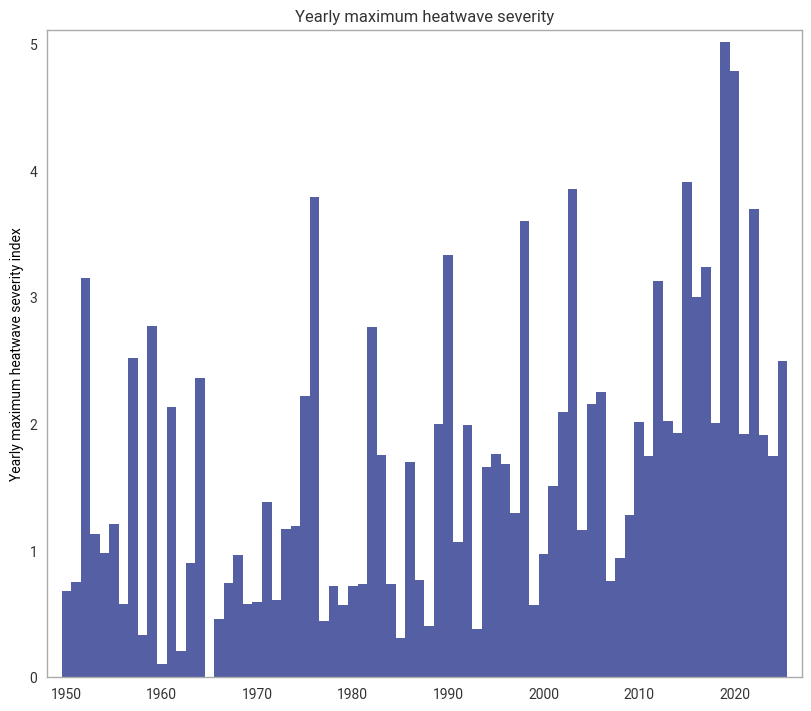

In [8]:
hsev_max_year = hsev.groupby("valid_time.year").max()

chart = ekp.Subplot()
chart.title("Yearly maximum heatwave severity")
chart.ax.bar(hsev_max_year["year"], hsev_max_year, width=1)
chart.ax.set_ylabel("Yearly maximum heatwave severity index")
chart.ax.grid(False)

## Excess heat and cold factor statistics

Compute and visualise extreme quantile statistics of the excess heat and cold factor as a function of day-of-year:

In [9]:
exhf_qs = exhf.groupby("valid_time.dayofyear").quantile([0.0, 0.95, 0.975, 1.0])
excf_qs = excf.groupby("valid_time.dayofyear").quantile([0.0, 0.025, 0.05, 1.0])

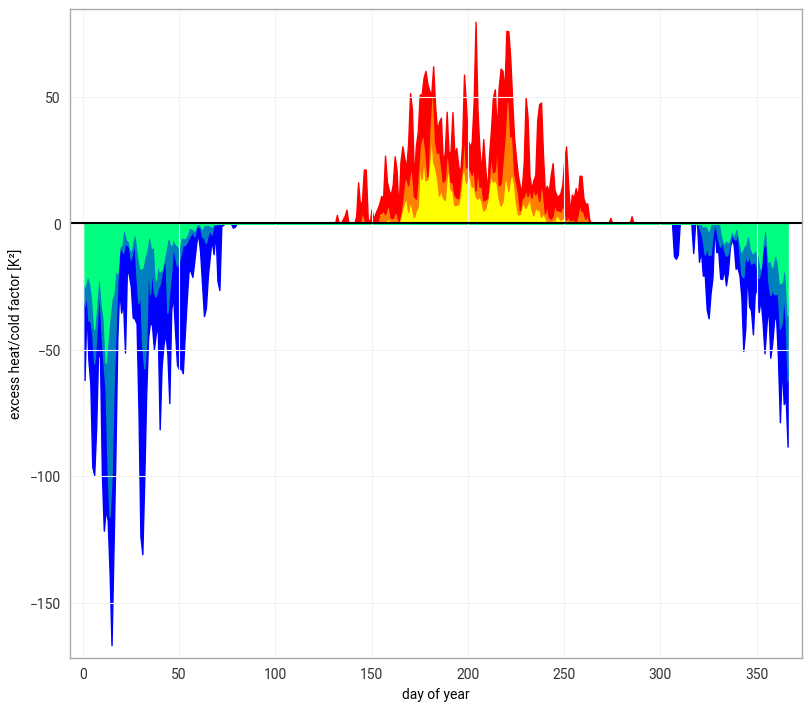

In [10]:
chart = ekp.Subplot()

# Statistics: quantiles
band_colors = plt.get_cmap("autumn_r")(np.linspace(0, 1, exhf_qs["quantile"].size-1))
bandplot(chart.ax, exhf_qs["dayofyear"], exhf_qs.T, colors=band_colors)

# Statistics: quantiles
band_colors = plt.get_cmap("winter")(np.linspace(0, 1, excf_qs["quantile"].size-1))
bandplot(chart.ax, excf_qs["dayofyear"], excf_qs.T, colors=band_colors)

chart.ax.set_xlabel("day of year")
chart.ax.set_ylabel("excess heat/cold factor [K²]")

chart.ax.axhline(0, color="k")

## Summer 2003 heatwave

Plot the excess heat factor together with daily mean temperature for the summer 2003, where a significant heatwave occurred over large parts of Europe:

In [11]:
summer2003 = {"valid_time": slice("2003-06", "2003-08")}

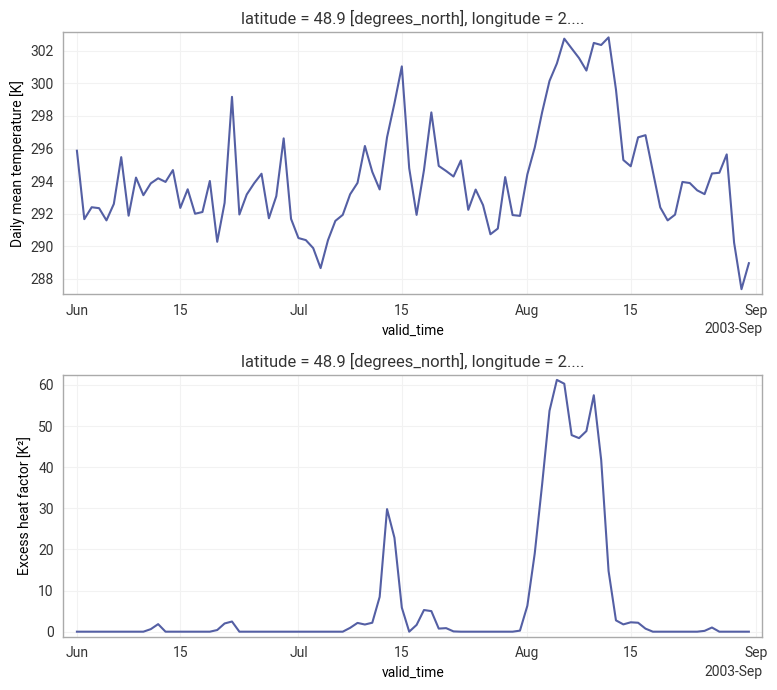

In [12]:
fig, axs = plt.subplots(2, 1)

dmt.sel(summer2003).plot(ax=axs[0])
exhf.sel(summer2003).plot(ax=axs[1])

fig.tight_layout()